# Trigger wave thresholds

In [1]:
import immunowave as iw
import numpy as np
import jax
import jax.numpy as jnp
import diffrax as dx

import matplotlib as mpl
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

## Model definition

Define the state and model for a simple model with a fixed point source bacterial stimulation.

In [2]:
class State(iw.State):
    A: iw.ScalarField

In [3]:
class Model(iw.Model):
    θ: float
    B0: float

    @jax.jit
    def __call__(self, t, state, impulse):
        # unpack field variables
        A = state.A
        # unpack parameters
        θ, B0 = self.θ, self.B0
        # define B field
        B = B0 * impulse
        # define PDE
        dAdt = A.laplacian(bc="neumann") + A * (A - θ) * (1 - A) + B
        # return vector field
        return State(dAdt)

### Tissue-level activation metric

Root-mean-squared norm of the antimicrobial concentration over the tissue
$\|A(\cdot,t)\|_2$ = $\sqrt{\frac{1}{L}\int_0^L A^2(x, t) dx}$

In [4]:
@jax.jit
def norm(state):
    L = (state.A.ub - state.A.lb).squeeze()
    return jnp.sqrt((state.A**2).integral() / L)

### Spatial domain

In [5]:
L = 200.0
n = 201

shape = (n,)
lb = [0]
h = L / (n - 1)

### Bacterial impulse

Approximate a Dirac impulse

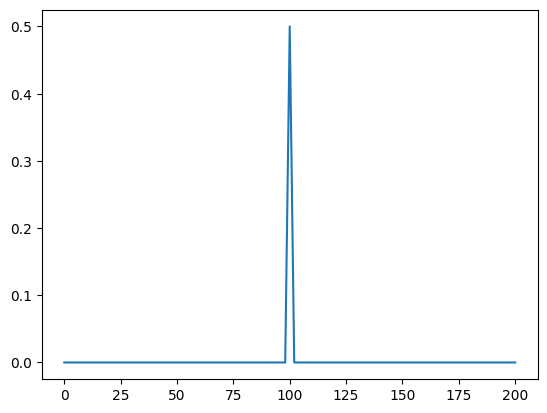

In [6]:
impulse = iw.ScalarField(
    shape,
    lb,
    h,
    # fn=lambda x: jax.scipy.stats.norm.pdf(x, loc=L / 2, scale=2 * h),
    fn=lambda x: jnp.heaviside(h + x - L / 2, 0.5)
    * jnp.heaviside(h - x + L / 2, 0.5)
    / (2 * h),
)

impulse.plot()
plt.show()

assert jnp.isclose(impulse.integral(), 1.0), impulse.integral()

### Initial state

$A(x, 0) = 0, \quad x \in [0, L]$

In [7]:
state = State(iw.ScalarField(shape, lb, h, 0))

We set the upper bound of the time domain to infinity, and then terminate integration when a steady state is reached.

In [8]:
t0 = 0.0
t1 = jnp.inf

atol = 1e-6
rtol = 1e-6

kwargs = dict(
    args=impulse,
    dt0=1e-4,
    max_steps=10000000,
    atol=atol,
    rtol=rtol,
    throw=True,
    discrete_terminating_event=dx.SteadyStateEvent(norm=norm, atol=atol, rtol=rtol),
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Example 1: low $B_0$

In [9]:
model = Model(θ=0.01, B0=1e-5)
model

Model(θ=0.01, B0=1e-05)

Solve

In [10]:
solution = iw.solve(model, state, t0, t1, **kwargs)

ValueError: `where` requires a scalar boolean predicate

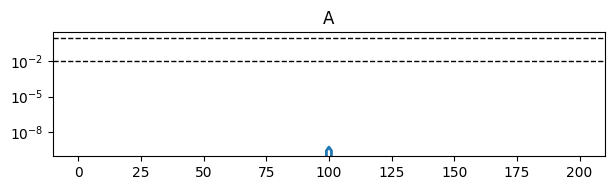

In [11]:
solution.ys.plot(time_idx=-1, lw=2)
plt.axhline(model.θ, color="black", linestyle="--", lw=1)
plt.axhline(1, color="black", linestyle="--", lw=1)
plt.yscale("log")
plt.show()

Steady state termination time $t^\ast$

In [12]:
solution.ts[-1]

Array(0.0001, dtype=float64)

RMS activation $\|A(\cdot, t^\ast)\|_2$ at time $t^\ast$

In [13]:
norm(solution.ys.map(lambda v: v[-1]))

Array(4.33012702e-11, dtype=float64)

## Example 2: high bacterial stimulus

In [14]:
model = Model(θ=0.01, B0=1e0)

In [15]:
solution = iw.solve(model, state, t0, t1, **kwargs)

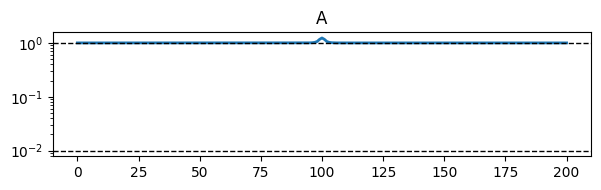

In [16]:
axes = solution.ys.plot(time_idx=-1, lw=2)
plt.axhline(model.θ, color="black", linestyle="--", lw=1)
plt.axhline(1, color="black", linestyle="--", lw=1)
# plt.ylim(0, None)
plt.yscale("log")
plt.show()

In [17]:
solution.ts[-1]

Array(155.2531, dtype=float64)

In [18]:
norm(solution.ys.map(lambda v: v[-1]))

Array(1.00404855, dtype=float64)

## Trigger thresholds

A function that takes $B_0$ and $\theta$, and returns the time $t^\ast$ when the integration was terminated by a steady state condition and the activation norm $\|A(\cdot,t^\ast)\|_2$ at that time.

In [19]:
@jax.jit
def response(B0, θ):
    model = Model(θ=θ, B0=B0)
    state = State(iw.ScalarField(shape, lb, h, 0))
    solution = iw.solve(model, state, t0, t1, **kwargs)
    return solution.ts[-1], norm(solution.ys.map(lambda v: v[-1]))

Construct grids of $t^\ast$ and $\|A(\cdot,t^\ast)\|_2$ for a range of $B_0$ and $\theta$ values.

In [20]:
θs = np.geomspace(0.01, 0.5, 30, endpoint=False)
B0s = np.geomspace(1e-3, 1.0, 30)

t_steady = np.zeros((len(θs), len(B0s)), dtype=np.float64)
norm_dat = np.zeros((len(θs), len(B0s)), dtype=np.float64)
for i, θ in enumerate(θs):
    for j, B0 in enumerate(B0s):
        t_steady[i, j], norm_dat[i, j] = response(B0, θ)
        print(
            f"{θ=:.4f}, {B0=:.4f}: t_steady={t_steady[i, j]:.2f}, norm={norm_dat[i, j]:.4f}",
            end=" \r",
        )

Plot $\|A(\cdot,t^\ast)\|_2$ as a function of $B_0$ and $\theta$, and compare to analytical approximations.

/var/folders/0w/l84hyz3n6ns582pxy6tkt8y80000gn/T/ipykernel_23706/2211564544.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(


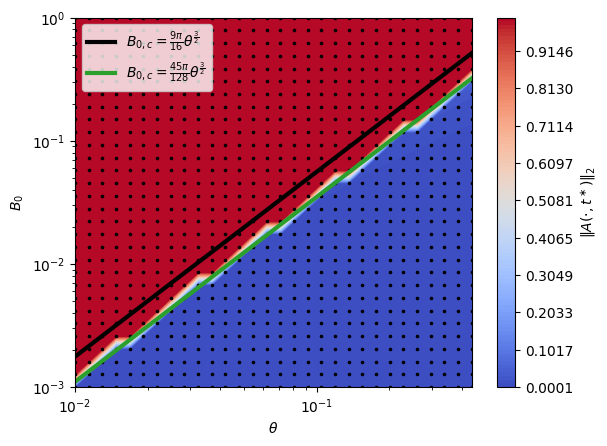

In [21]:
levels = np.linspace(norm_dat.min(), norm_dat.max(), 100)

plt.contourf(θs, B0s, norm_dat.T, levels=levels, cmap="coolwarm")
plt.colorbar(label=r"$\|A(\cdot,t^\ast)\|_2$")
plt.scatter(
    *np.meshgrid(θs, B0s),
    c="k",
    s=10,
    cmap="coolwarm",
    vmin=levels[0],
    vmax=levels[-1],
    marker=".",
)
plt.plot(
    θs,
    (9 * np.pi / 16) * θs ** (3 / 2),
    c="k",
    ls="-",
    lw=3,
    label=r"$B_{0,c} = \frac{9\pi}{16}\theta^\frac{3}{2}$",
)
plt.plot(
    θs,
    (45 * np.pi / 128) * θs ** (3 / 2),
    c="C2",
    ls="-",
    lw=3,
    label=r"$B_{0,c} = \frac{45\pi}{128}\theta^\frac{3}{2}$",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$B_0$")
plt.xlim(θs[0], θs[-1])
plt.ylim(B0s[0], B0s[-1])
plt.legend(loc="upper left")
plt.show()

Plot termination times $t^\ast$

/var/folders/0w/l84hyz3n6ns582pxy6tkt8y80000gn/T/ipykernel_23706/2112357637.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(


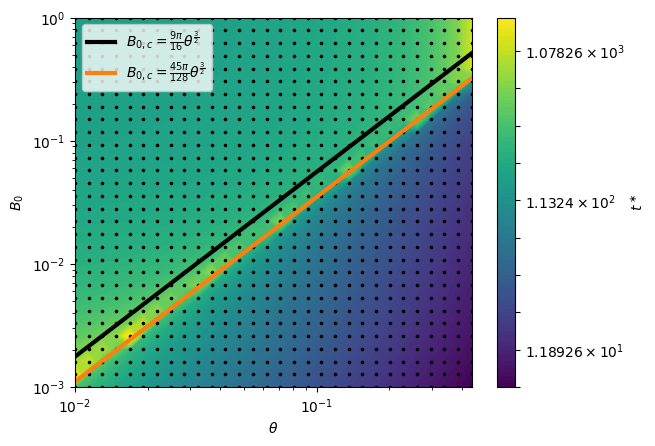

In [22]:
levels = np.geomspace(t_steady.min(), t_steady.max(), 100)
cnorm = mpl.colors.LogNorm(vmin=t_steady.min(), vmax=t_steady.max())

plt.contourf(θs, B0s, t_steady.T, levels=levels, cmap="viridis", norm=cnorm)
plt.colorbar(label=r"$t^\ast$")
plt.scatter(
    *np.meshgrid(θs, B0s),
    c="k",
    s=10,
    cmap="coolwarm",
    vmin=levels[0],
    vmax=levels[-1],
    marker=".",
)
plt.plot(
    θs,
    (9 * np.pi / 16) * θs ** (3 / 2),
    c="k",
    ls="-",
    lw=3,
    label=r"$B_{0,c} = \frac{9\pi}{16}\theta^\frac{3}{2}$",
)
plt.plot(
    θs,
    (45 * np.pi / 128) * θs ** (3 / 2),
    c="C1",
    ls="-",
    lw=3,
    label=r"$B_{0,c} = \frac{45\pi}{128}\theta^\frac{3}{2}$",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$B_0$")
plt.xlim(θs[0], θs[-1])
plt.ylim(B0s[0], B0s[-1])
plt.legend(loc="upper left")
plt.show()

In [ ]:
0.